# Лабораторная работа 
### Выполнил: Гришков Василий Александрович, ПМИ-МФТИ-1-2023

### Конфиг

In [28]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from collections import defaultdict
import time
import os


K_NEIGHBORS = 20           # число соседей для KNN
TOP_X = 10                 # сколько рекомендаций выдавать
TEST_SIZE = 0.2            # доля данных на тест (per-user)
RELEVANCE_THRESHOLD = 4.0  # рейтинг >= порога = "релевантный" фильм
RANDOM_STATE = 42

### Preprocessing (подготовка данных)


In [40]:
path = 'ml-1m'
ratings = pd.read_csv(
    os.path.join(path, 'ratings.dat'),
    sep='::', engine='python', header=None,
    names=['userId', 'movieId', 'rating', 'timestamp'],
    encoding='latin-1'
)
movies = pd.read_csv(
    os.path.join(path, 'movies.dat'),
    sep='::', engine='python', header=None,
    names=['movieId', 'title', 'genres'],
    encoding='latin-1'
)
users = pd.read_csv(
    os.path.join(path, 'users.dat'),
    sep='::', engine='python', header=None,
    names=['userId', 'gender', 'age', 'occupation', 'zip'],
    encoding='latin-1'
)

movie_title = movies.set_index('movieId')['title'].to_dict()

def get_title(mid):
    return movie_title.get(mid, f'Unknown({mid})')

### EDA (исследовательский анализ данных)

In [41]:
n_users_total = ratings['userId'].nunique()
n_movies_total = ratings['movieId'].nunique()
sparsity = 1 - len(ratings) / (n_users_total * n_movies_total)

print(f"Оценок:       {len(ratings):>10,}")
print(f"Пользователей:{n_users_total:>10,}")
print(f"Фильмов:      {n_movies_total:>10,}")
print(f"Разреженность: {sparsity:.4f} ({sparsity*100:.2f}%)")

print(f"\nРаспределение оценок:")
print(ratings['rating'].value_counts().sort_index())

print(f"\nОценок на пользователя: "
      f"min={ratings.groupby('userId').size().min()}, "
      f"median={ratings.groupby('userId').size().median():.0f}, "
      f"mean={ratings.groupby('userId').size().mean():.0f}, "
      f"max={ratings.groupby('userId').size().max()}")

print(f"Оценок на фильм:       "
      f"min={ratings.groupby('movieId').size().min()}, "
      f"median={ratings.groupby('movieId').size().median():.0f}, "
      f"mean={ratings.groupby('movieId').size().mean():.0f}, "
      f"max={ratings.groupby('movieId').size().max()}")

Оценок:        1,000,209
Пользователей:     6,040
Фильмов:           3,706
Разреженность: 0.9553 (95.53%)

Распределение оценок:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

Оценок на пользователя: min=20, median=96, mean=166, max=2314
Оценок на фильм:       min=1, median=124, mean=270, max=3428


### Train/test

In [43]:
def train_test_split_per_user(df, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_parts, test_parts = [], []

    for _, group in df.groupby('userId'):
        n_test = max(1, int(len(group) * test_size))
        test_idx = rng.choice(group.index, size=n_test, replace=False)
        train_parts.append(group.drop(test_idx))
        test_parts.append(group.loc[test_idx])

    return pd.concat(train_parts), pd.concat(test_parts)


train_df, test_df = train_test_split_per_user(ratings, TEST_SIZE, RANDOM_STATE)
print(f"\nTrain: {len(train_df):,} оценок")
print(f"Test:  {len(test_df):,} оценок")


all_user_ids  = sorted(ratings['userId'].unique())
all_movie_ids = sorted(ratings['movieId'].unique())

user2idx  = {u: i for i, u in enumerate(all_user_ids)}
movie2idx = {m: i for i, m in enumerate(all_movie_ids)}
idx2user  = {i: u for u, i in user2idx.items()}
idx2movie = {i: m for m, i in movie2idx.items()}

N_USERS  = len(all_user_ids)
N_MOVIES = len(all_movie_ids)

def normalize_matrix(matrix):
    matrix = matrix.copy().astype(np.float64)
    
    user_means = []
    for i in range(matrix.shape[0]):
        row = matrix[i]
        if row.nnz > 0:
            mean = row.data.mean()
            row.data -= mean
            user_means.append(mean)
        else:
            user_means.append(0)
    
    return matrix, np.array(user_means)


def to_sparse(df):
    rows = df['userId'].map(user2idx).values
    cols = df['movieId'].map(movie2idx).values
    vals = df['rating'].values.astype(np.float32)
    return csr_matrix((vals, (rows, cols)), shape=(N_USERS, N_MOVIES))

train_matrix = to_sparse(train_df)
train_normalized, user_means = normalize_matrix(train_matrix)

print(f"Матрица user-item: {train_matrix.shape}")


Train: 802,553 оценок
Test:  197,656 оценок
Матрица user-item: (6040, 3706)


### Метрики

Реализуйте функцию, которая бы делала предсказания. Функция принимает датасет/даталоадер и модель (мб еще что-то). Эта функция нужна вам, чтобы было удобнее считать метрику (по сути она будет склеивать предсказания из батчей в один массив). 

In [45]:
def precision_at_k(recs, relevant, k):
    return len(set(recs[:k]) & relevant) / k if k else 0.0

def recall_at_k(recs, relevant, k):
    return len(set(recs[:k]) & relevant) / len(relevant) if relevant else 0.0

def ndcg_at_k(recs, relevant, k):
    dcg  = sum(1/np.log2(i+2) for i, r in enumerate(recs[:k]) if r in relevant)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def map_at_k(recs, relevant, k):
    hits, s = 0, 0.0
    for i, r in enumerate(recs[:k]):
        if r in relevant:
            hits += 1
            s += hits / (i + 1)
    return s / min(len(relevant), k) if relevant else 0.0

def hit_at_k(recs, relevant, k):
    return 1.0 if set(recs[:k]) & relevant else 0.0


def evaluate(recommend_fn, test_df, top_x,
             threshold=RELEVANCE_THRESHOLD, max_users=None):
    gt = (test_df[test_df['rating'] >= threshold]
          .groupby('userId')['movieId']
          .apply(set).to_dict())

    eval_users = list(gt.keys())
    if max_users and max_users < len(eval_users):
        rng = np.random.RandomState(RANDOM_STATE)
        eval_users = list(rng.choice(eval_users, max_users, replace=False))

    acc = defaultdict(list)
    all_recs = set()
    t0 = time.time()

    for i, uid in enumerate(eval_users):
        if (i+1) % 1000 == 0:
            print(f"    ... {i+1}/{len(eval_users)}  "
                  f"({time.time()-t0:.0f}s)")
        recs = recommend_fn(uid, top_x)
        rel = gt[uid]
        if not rel:
            continue
        all_recs.update(recs)
        acc['Precision'].append(precision_at_k(recs, rel, top_x))
        acc['Recall'].append(recall_at_k(recs, rel, top_x))
        acc['NDCG'].append(ndcg_at_k(recs, rel, top_x))
        acc['MAP'].append(map_at_k(recs, rel, top_x))
        acc['HitRate'].append(hit_at_k(recs, rel, top_x))

    elapsed = time.time() - t0
    res = {k: np.mean(v) for k, v in acc.items()}
    res['F1'] = (2 * res['Precision'] * res['Recall']
                   / (res['Precision'] + res['Recall'])
                   if (res['Precision'] + res['Recall']) > 0 else 0)
    res['Coverage'] = len(all_recs) / N_MOVIES
    res['Users_evaluated'] = len(acc['Precision'])
    res['Time_sec'] = round(elapsed, 1)
    return res


def print_metrics(name, m):
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    for k, v in m.items():
        fmt = f"{v:.4f}" if isinstance(v, float) else str(v)
        print(f"  {k:<20s} {fmt}")

### Задания

#### Задание 1 (item-based)

In [46]:
class ItemBasedKNN:
    def __init__(self, k=30, metric='cosine', min_sim=0.1):
        self.k = k
        self.metric = metric
        self.min_sim = min_sim

    def fit(self, user_item_matrix):
        self.raw_mat = user_item_matrix
        self.mat, self.user_means = self._normalize(user_item_matrix)
        
        item_mat = self.mat.T.tocsr()
        
        knn = NearestNeighbors(
            n_neighbors=min(self.k + 1, item_mat.shape[0]),
            metric=self.metric, algorithm='brute')
        knn.fit(item_mat)
        
        self.dist, self.ind = knn.kneighbors(item_mat)
        self.item_mat = item_mat

    def _normalize(self, matrix):
        matrix = matrix.copy().toarray().astype(np.float64)
        user_means = np.zeros(matrix.shape[0])
        for i in range(matrix.shape[0]):
            mask = matrix[i] != 0
            if mask.any():
                user_means[i] = matrix[i, mask].mean()
                matrix[i, mask] -= user_means[i]
        return csr_matrix(matrix), user_means

    def recommend(self, user_id, top_x=10):
        if user_id not in user2idx:
            return []
        uidx = user2idx[user_id]
        
        raw_vec = self.raw_mat[uidx].toarray().ravel()
        rated = set(np.nonzero(raw_vec)[0])
        if not rated:
            return []
        
        norm_vec = self.mat[uidx].toarray().ravel()
        
        scores, weights = defaultdict(float), defaultdict(float)
        
        for item_idx in rated:
            deviation = norm_vec[item_idx]
            for j in range(1, min(self.k + 1, len(self.ind[item_idx]))):
                nb = self.ind[item_idx][j]
                if nb in rated:
                    continue
                sim = 1 - self.dist[item_idx][j]
                if sim < self.min_sim:
                    continue
                scores[nb]  += sim * deviation
                weights[nb] += abs(sim)
        
        user_mean = self.user_means[uidx]
        preds = {}
        for i in scores:
            if weights[i] > 0:
                pred = user_mean + scores[i] / weights[i]
                if pred >= 3.5:
                    preds[i] = pred
        
        top = sorted(preds, key=preds.get, reverse=True)[:top_x]
        return [idx2movie[i] for i in top]

    def similar_items(self, movie_id, top_x=10):
        if movie_id not in movie2idx:
            return []
        idx = movie2idx[movie_id]
        out = []
        for j in range(1, min(top_x + 1, len(self.ind[idx]))):
            sim = 1 - self.dist[idx][j]
            if sim < self.min_sim:
                continue
            out.append((idx2movie[self.ind[idx][j]], sim))
        return out

Обучаем модель

In [52]:
print(f"  K={K_NEIGHBORS}, Top={TOP_X}, test_size={TEST_SIZE}")

item_cf = ItemBasedKNN(k=K_NEIGHBORS)
item_cf.fit(train_matrix)

demo_movies = [1, 260, 1196]
for mid in demo_movies:
    print(f"\nПохожие на «{get_title(mid)}»:")
    for sim_mid, sim in item_cf.similar_items(mid, TOP_X):
        print(f"   {sim:.3f}  {get_title(sim_mid)}")

demo_user = 1
user_train = train_df[train_df['userId'] == demo_user].sort_values('rating', ascending=False)
print(f"\n Пользователь {demo_user} - оценки (train, топ-10):")
for _, row in user_train.head(10).iterrows():
    print(f"  {row['rating']:.0f}  {get_title(row['movieId'])}")

recs = item_cf.recommend(demo_user, TOP_X)
print(f"\n Item-Based рекомендации для User {demo_user}:")
for i, mid in enumerate(recs, 1):
    print(f"   {i:2d}. {get_title(mid)}")

  K=20, Top=10, test_size=0.2

Похожие на «Toy Story (1995)»:
   0.401  Toy Story 2 (1999)
   0.246  Bug's Life, A (1998)
   0.234  Raiders of the Lost Ark (1981)
   0.222  Star Wars: Episode V - The Empire Strikes Back (1980)
   0.219  Star Wars: Episode IV - A New Hope (1977)
   0.216  Aladdin (1992)
   0.216  Back to the Future (1985)
   0.213  Sixth Sense, The (1999)
   0.211  Shawshank Redemption, The (1994)
   0.211  Lion King, The (1994)

Похожие на «Star Wars: Episode IV - A New Hope (1977)»:
   0.540  Star Wars: Episode V - The Empire Strikes Back (1980)
   0.455  Raiders of the Lost Ark (1981)
   0.386  Star Wars: Episode VI - Return of the Jedi (1983)
   0.343  Matrix, The (1999)
   0.324  Terminator, The (1984)
   0.321  Godfather, The (1972)
   0.316  Princess Bride, The (1987)
   0.314  Indiana Jones and the Last Crusade (1989)
   0.277  Schindler's List (1993)
   0.277  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)

Похожие на «Star Wars: Ep

In [53]:
print("Оцениваем Item-Based на тестовой выборке")
item_metrics = evaluate(item_cf.recommend, test_df, TOP_X)
print_metrics("ITEM-BASED CF", item_metrics)

Оцениваем Item-Based на тестовой выборке
    ... 1000/6012  (2s)
    ... 2000/6012  (4s)
    ... 3000/6012  (6s)
    ... 4000/6012  (8s)
    ... 5000/6012  (10s)
    ... 6000/6012  (12s)

────────────────────────────────────────
  ITEM-BASED CF
────────────────────────────────────────
  Precision            0.0248
  Recall               0.0226
  NDCG                 0.0326
  MAP                  0.0131
  HitRate              0.2099
  F1                   0.0236
  Coverage             0.8324
  Users_evaluated      6012
  Time_sec             12.3000


#### Задание 2 (User-based)

In [54]:
class UserBasedKNN:
    def __init__(self, k=20, metric='cosine'):
        self.k = k
        self.metric = metric

    def fit(self, user_item_matrix):
        self.mat = user_item_matrix

        knn = NearestNeighbors(
            n_neighbors=min(self.k + 1, user_item_matrix.shape[0]),
            metric=self.metric, algorithm='brute')
        knn.fit(user_item_matrix)

        self.dist, self.ind = knn.kneighbors(user_item_matrix)

    def similar_users(self, user_id, top_x=5):
        if user_id not in user2idx:
            return []
        idx = user2idx[user_id]
        out = []
        for j in range(1, min(top_x + 1, len(self.ind[idx]))):
            sim = 1 - self.dist[idx][j]
            if not (sim > 0):
                continue
            out.append((idx2user[self.ind[idx][j]], sim))
        return out

    def recommend(self, user_id, top_x=10):
        if user_id not in user2idx:
            return []
        uidx = user2idx[user_id]
        uvec = self.mat[uidx].toarray().ravel()
        rated = set(np.nonzero(uvec)[0])

        scores, weights = defaultdict(float), defaultdict(float)
        for j in range(1, min(self.k + 1, len(self.ind[uidx]))):
            sim = 1 - self.dist[uidx][j]
            if not (sim > 0):
                continue
            nb_idx = self.ind[uidx][j]
            nb_vec = self.mat[nb_idx].toarray().ravel()
            for item_idx in np.nonzero(nb_vec)[0]:
                if item_idx in rated:
                    continue
                scores[item_idx]  += sim * nb_vec[item_idx]
                weights[item_idx] += sim

        preds = {i: scores[i]/weights[i] for i in scores if weights[i] > 0}
        top = sorted(preds, key=preds.get, reverse=True)[:top_x]
        return [idx2movie[i] for i in top]

In [56]:
print(f"  K={K_NEIGHBORS}, Top={TOP_X}, test_size={TEST_SIZE}")

user_cf = UserBasedKNN(k=K_NEIGHBORS)
user_cf.fit(train_normalized)

print(f"\n Ближайшие соседи User {demo_user}:")
for uid, sim in user_cf.similar_users(demo_user, 5):
    n_common = len(
        set(train_df[train_df['userId']==demo_user]['movieId']) &
        set(train_df[train_df['userId']==uid]['movieId'])
    )
    print(f"   User {uid:>5d}  sim={sim:.3f}  "
          f"(общих фильмов: {n_common})")

recs = user_cf.recommend(demo_user, TOP_X)
print(f"\n User-Based рекомендации для User {demo_user}:")
for i, mid in enumerate(recs, 1):
    print(f"   {i:2d}. {get_title(mid)}")

  K=20, Top=10, test_size=0.2

 Ближайшие соседи User 1:
   User  1481  sim=0.351  (общих фильмов: 20)
   User  1476  sim=0.334  (общих фильмов: 15)
   User  5762  sim=0.333  (общих фильмов: 30)
   User    80  sim=0.311  (общих фильмов: 12)
   User  5705  sim=0.311  (общих фильмов: 22)

 User-Based рекомендации для User 1:
    1. Mr. Smith Goes to Washington (1939)
    2. Casablanca (1942)
    3. Gone with the Wind (1939)
    4. Shall We Dance? (Shall We Dansu?) (1996)
    5. Fast, Cheap & Out of Control (1997)
    6. Dark City (1998)
    7. Doctor Zhivago (1965)
    8. Drunken Master (Zui quan) (1979)
    9. Princess Mononoke, The (Mononoke Hime) (1997)
   10. Sense and Sensibility (1995)


In [57]:
print("Оцениваем User-Based на тестовой")
user_metrics = evaluate(user_cf.recommend, test_df, TOP_X)
print_metrics("USER-BASED метрики", user_metrics)

Оцениваем User-Based на тестовой
    ... 1000/6012  (3s)
    ... 2000/6012  (6s)
    ... 3000/6012  (9s)
    ... 4000/6012  (13s)
    ... 5000/6012  (16s)
    ... 6000/6012  (19s)

────────────────────────────────────────
  USER-BASED метрики
────────────────────────────────────────
  Precision            0.0103
  Recall               0.0106
  NDCG                 0.0146
  MAP                  0.0058
  HitRate              0.0961
  F1                   0.0105
  Coverage             0.7237
  Users_evaluated      6012
  Time_sec             18.8000


#### Сравнение

In [58]:
print("СРАВНЕНИЕ ITEM-BASED vs USER-BASED")

cmp = pd.DataFrame({
    'Item-Based': item_metrics,
    'User-Based': user_metrics
})

print(cmp.to_string())

СРАВНЕНИЕ ITEM-BASED vs USER-BASED
                  Item-Based   User-Based
Precision           0.024767     0.010346
Recall              0.022581     0.010604
NDCG                0.032564     0.014560
MAP                 0.013087     0.005824
HitRate             0.209914     0.096141
F1                  0.023624     0.010473
Coverage            0.832434     0.723691
Users_evaluated  6012.000000  6012.000000
Time_sec           12.300000    18.800000


### Чувствительность

In [61]:
SAMPLE_USERS = 1000

print("ЭКСПЕРИМЕНТ 1: Влияние K (число соседей)")

k_values = [3, 5, 10, 20, 50, 100]
results_k = []

for k in k_values:
    print(f"\n--- K = {k} ---")
    icf = ItemBasedKNN(k=k); icf.fit(train_matrix)
    mi = evaluate(icf.recommend, test_df, TOP_X, max_users=SAMPLE_USERS)

    ucf = UserBasedKNN(k=k); ucf.fit(train_matrix)
    mu = evaluate(ucf.recommend, test_df, TOP_X, max_users=SAMPLE_USERS)

    results_k.append({
        'K': k,
        'Item_Prec': mi['Precision'], 'Item_Recall': mi['Recall'],
        'Item_NDCG': mi['NDCG'],      'Item_MAP': mi['MAP'],
        'User_Prec': mu['Precision'], 'User_Recall': mu['Recall'],
        'User_NDCG': mu['NDCG'],      'User_MAP': mu['MAP'],
    })
    print(f"  Item-Based: P={mi['Precision']:.4f} R={mi['Recall']:.4f} "
          f"NDCG={mi['NDCG']:.4f}")
    print(f"  User-Based: P={mu['Precision']:.4f} R={mu['Recall']:.4f} "
          f"NDCG={mu['NDCG']:.4f}")

df_k = pd.DataFrame(results_k).set_index('K')
print(f"\n{df_k.to_string()}")



print("ЭКСПЕРИМЕНТ 2: Влияние Top X")

top_values = [5, 10, 20, 50]
results_top = []

for tx in top_values:
    mi = evaluate(item_cf.recommend, test_df, tx, max_users=SAMPLE_USERS)
    mu = evaluate(user_cf.recommend, test_df, tx, max_users=SAMPLE_USERS)
    results_top.append({
        'Top_X': tx,
        'Item_Prec': mi['Precision'], 'Item_Recall': mi['Recall'],
        'Item_NDCG': mi['NDCG'],
        'User_Prec': mu['Precision'], 'User_Recall': mu['Recall'],
        'User_NDCG': mu['NDCG'],
    })

df_top = pd.DataFrame(results_top).set_index('Top_X')
print(f"\n{df_top.to_string()}")

print("ЭКСПЕРИМЕНТ 3: Влияние доли тестовой выборки")

test_sizes = [0.1, 0.2, 0.3, 0.4]
results_ts = []

for ts in test_sizes:
    tr, te = train_test_split_per_user(ratings, ts, RANDOM_STATE)
    mat = to_sparse(tr)

    icf = ItemBasedKNN(k=K_NEIGHBORS); icf.fit(mat)
    ucf = UserBasedKNN(k=K_NEIGHBORS); ucf.fit(mat)

    mi = evaluate(icf.recommend, te, TOP_X, max_users=SAMPLE_USERS)
    mu = evaluate(ucf.recommend, te, TOP_X, max_users=SAMPLE_USERS)

    results_ts.append({
        'TestSize': ts,
        'Train_ratings': len(tr),
        'Item_Prec': mi['Precision'], 'Item_NDCG': mi['NDCG'],
        'User_Prec': mu['Precision'], 'User_NDCG': mu['NDCG'],
    })

df_ts = pd.DataFrame(results_ts).set_index('TestSize')
print(f"\n{df_ts.to_string()}")

ЭКСПЕРИМЕНТ 1: Влияние K (число соседей)

--- K = 3 ---
    ... 1000/1000  (1s)
    ... 1000/1000  (1s)
  Item-Based: P=0.0577 R=0.0507 NDCG=0.0704
  User-Based: P=0.0858 R=0.0780 NDCG=0.1090

--- K = 5 ---
    ... 1000/1000  (1s)
    ... 1000/1000  (1s)
  Item-Based: P=0.0445 R=0.0401 NDCG=0.0551
  User-Based: P=0.0616 R=0.0548 NDCG=0.0779

--- K = 10 ---
    ... 1000/1000  (1s)
    ... 1000/1000  (2s)
  Item-Based: P=0.0290 R=0.0283 NDCG=0.0385
  User-Based: P=0.0293 R=0.0277 NDCG=0.0406

--- K = 20 ---
    ... 1000/1000  (2s)
    ... 1000/1000  (3s)
  Item-Based: P=0.0219 R=0.0203 NDCG=0.0305
  User-Based: P=0.0098 R=0.0103 NDCG=0.0141

--- K = 50 ---
    ... 1000/1000  (4s)
    ... 1000/1000  (7s)
  Item-Based: P=0.0164 R=0.0129 NDCG=0.0221
  User-Based: P=0.0025 R=0.0032 NDCG=0.0039

--- K = 100 ---
    ... 1000/1000  (7s)
    ... 1000/1000  (14s)
  Item-Based: P=0.0137 R=0.0105 NDCG=0.0173
  User-Based: P=0.0008 R=0.0007 NDCG=0.0010

     Item_Prec  Item_Recall  Item_NDCG  Item_M

### Визуализация

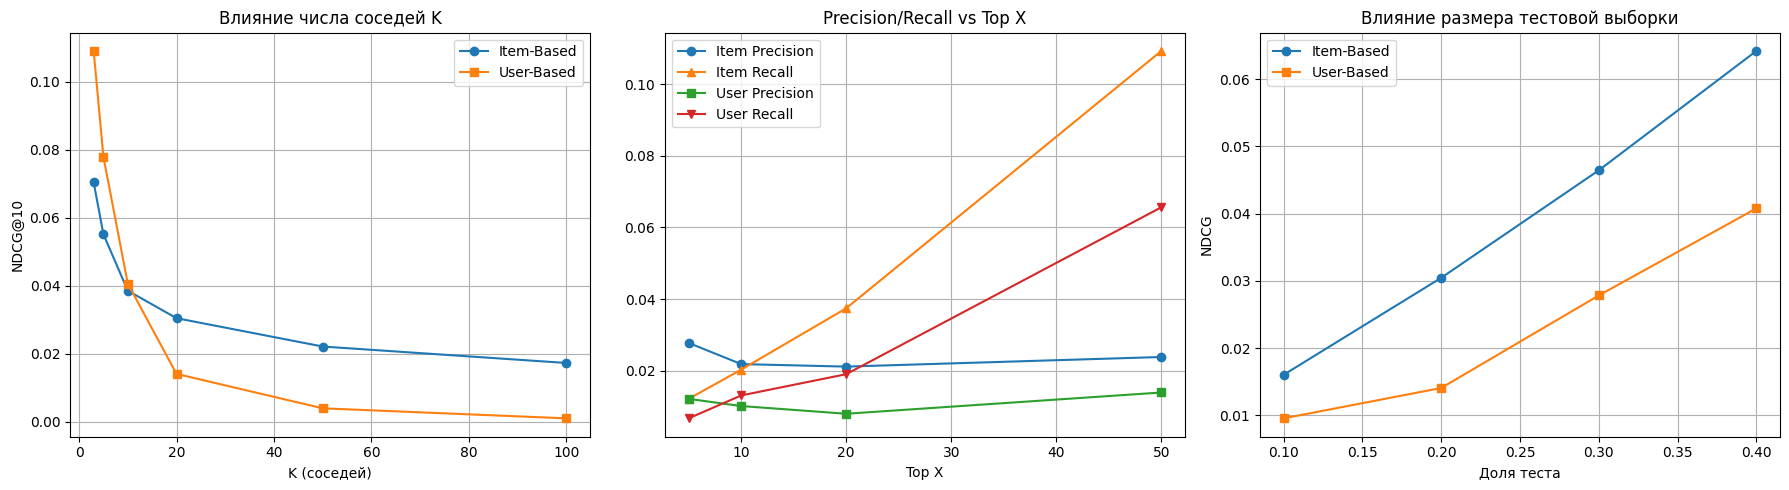

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(df_k.index, df_k['Item_NDCG'], 'o-', label='Item-Based')
ax.plot(df_k.index, df_k['User_NDCG'], 's-', label='User-Based')
ax.set_xlabel('K (соседей)'); ax.set_ylabel('NDCG@10')
ax.set_title('Влияние числа соседей K'); ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(df_top.index, df_top['Item_Prec'], 'o-', label='Item Precision')
ax.plot(df_top.index, df_top['Item_Recall'], '^-', label='Item Recall')
ax.plot(df_top.index, df_top['User_Prec'], 's-', label='User Precision')
ax.plot(df_top.index, df_top['User_Recall'], 'v-', label='User Recall')
ax.set_xlabel('Top X'); ax.set_title('Precision/Recall vs Top X')
ax.legend(); ax.grid(True)

ax = axes[2]
ax.plot(df_ts.index, df_ts['Item_NDCG'], 'o-', label='Item-Based')
ax.plot(df_ts.index, df_ts['User_NDCG'], 's-', label='User-Based')
ax.set_xlabel('Доля теста'); ax.set_ylabel('NDCG')
ax.set_title('Влияние размера тестовой выборки'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('cf_experiments.png', dpi=150)
plt.show()